In [1]:

# Homework 1 — Sector Deep Dive: Real Estate

# ============================================================
# 0. Setup and Sector Filter
# ============================================================

# pandas is used for data loading, cleaning, filtering and aggregation.
import pandas as pd

# numpy is useful for numerical operations.
import numpy as np

# matplotlib is used for plotting charts.
import matplotlib.pyplot as plt

# FuncFormatter helps format axis labels in a readable way.
from matplotlib.ticker import FuncFormatter

# Display settings to make tables easier to inspect.
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

# Default chart style settings.
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.grid"] = False

In [2]:
# ============================================================
# Helper functions for cleaner charts
# ============================================================

# Format values expressed in USD billions.
def billions_formatter(x, pos):
    return f"{x:,.0f}B"

# Format percentages.
def pct_formatter(x, pos):
    return f"{x:.0f}%"

# Remove unnecessary chart borders.
def clean_spines(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax

# Add labels to horizontal bar charts.
def annotate_hbar(ax, fmt="{:.1f}"):
    for patch in ax.patches:
        width = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        ax.text(width, y, "  " + fmt.format(width), va="center", fontsize=10)

In [3]:



# Load the full dataset from the data folder.
df_raw = pd.read_csv("data/symbol_info_3-25.csv")

# Inspect shape and first rows.
print("Raw dataset shape:", df_raw.shape)
df_raw.head()



Raw dataset shape: (1000, 38)


,symbol,company_name,sector,industry,market_cap,enterprise_value,current_price,previous_close,fifty_two_week_high,fifty_two_week_low,fifty_day_average,two_hundred_day_avg,beta,pe_trailing,pe_forward,price_to_sales,price_to_book,total_revenue,net_income,profit_margins,free_cashflow,debt_to_equity,return_on_assets,return_on_equity,revenue_growth,earnings_growth,last_annual_dividend,dividend_yield,payout_ratio,average_volume,short_ratio,exchange,exchange_short_name,country,is_etf,is_fund,is_actively_trading,timestamp
0,AAPL,Apple Inc.,Technology,Consumer Electronics,3278873821184,3321891913728,218.270004,214.100006,260.100006,164.080002,231.919006,228.354950,1.178,34.591125,26.265944,8.285006,49.182064,395760009216,96150003712,0.24295,93833871360,145.000000,0.22519,1.36520,0.040,0.101,1.00,0.46,0.1571,52181373,2.71,NMS,NMS,United States,0,0,1,2025-03-22 04:50:05
1,MSFT,Microsoft Corporation,Technology,Software - Infrastructure,2908619014144,2939973795840,391.260010,386.839996,468.350006,376.910004,408.945801,423.364349,0.914,31.553228,26.171238,11.109996,9.610435,261802000384,92749996032,0.35428,51958124544,33.998001,0.14649,0.34291,0.123,0.102,3.32,0.85,0.2482,22370941,2.68,NMS,NMS,United States,0,0,1,2025-03-22 04:50:07
2,NVDA,NVIDIA Corporation,Technology,Semiconductors,2892136185856,2838940090368,117.699997,118.529999,153.130005,75.606003,126.937798,127.763115,1.765,40.034012,28.567961,22.162472,36.315952,130497003520,72879996928,0.55848,44169748480,12.946000,0.57417,1.19177,0.779,0.836,0.04,0.03,0.0116,271988186,0.84,NMS,NMS,United States,0,0,1,2025-03-22 04:50:06
3,AMZN,"Amazon.com, Inc.",Consumer Cyclical,Internet Retail,2079374704640,2133579530240,196.210007,194.949997,242.520004,151.610001,218.631393,199.768295,1.192,35.481014,31.904066,3.259417,7.268114,637959012352,59248001024,0.09287,44635873280,54.341999,0.07438,0.24290,0.105,0.846,0.00,0.00,0.0000,38226331,1.78,NMS,NMS,United States,0,0,1,2025-03-22 04:50:08
4,GOOGL,Alphabet Inc.,Communication Services,Internet Content & Information,1996906430464,1931518148608,163.990005,162.800003,207.050003,147.220001,182.666000,175.225204,1.025,20.396767,18.302456,5.705153,6.159943,350018011136,100118003712,0.28604,56580751360,8.655000,0.16740,0.32908,0.118,0.309,0.80,0.49,0.0746,29147868,2.01,NMS,NMS,United States,0,0,1,2025-03-22 04:50:09


In [4]:
df_raw.columns.tolist()

['symbol',
 'company_name',
 'sector',
 'industry',
 'market_cap',
 'enterprise_value',
 'current_price',
 'previous_close',
 'fifty_two_week_high',
 'fifty_two_week_low',
 'fifty_day_average',
 'two_hundred_day_avg',
 'beta',
 'pe_trailing',
 'pe_forward',
 'price_to_sales',
 'price_to_book',
 'total_revenue',
 'net_income',
 'profit_margins',
 'free_cashflow',
 'debt_to_equity',
 'return_on_assets',
 'return_on_equity',
 'revenue_growth',
 'earnings_growth',
 'last_annual_dividend',
 'dividend_yield',
 'payout_ratio',
 'average_volume',
 'short_ratio',
 'exchange',
 'exchange_short_name',
 'country',
 'is_etf',
 'is_fund',
 'is_actively_trading',
 'timestamp']

In [5]:

# Inspect columns, data types and missing values

summary = pd.DataFrame({
    "column": df_raw.columns,
    "dtype": df_raw.dtypes.astype(str).values,
    "missing_values": df_raw.isna().sum().values,
    "missing_pct": (df_raw.isna().mean().values * 100).round(2)
})

summary.sort_values("missing_pct", ascending=False)

,column,dtype,missing_values,missing_pct
3,industry,object,2,0.2
2,sector,object,2,0.2
33,country,object,2,0.2
1,company_name,object,0,0.0
4,market_cap,int64,0,0.0
0,symbol,object,0,0.0
5,enterprise_value,uint64,0,0.0
6,current_price,float64,0,0.0
8,fifty_two_week_high,float64,0,0.0
7,previous_close,float64,0,0.0


In [6]:


# Start from the raw dataset.
df = df_raw.copy()

# Keep only actively traded companies.
df = df[df["is_actively_trading"] == 1].copy()

# Remove ETFs and funds because the homework focuses on operating companies.
df = df[(df["is_etf"] == 0) & (df["is_fund"] == 0)].copy()

# Create more readable financial columns expressed in USD billions.
df["market_cap_b"] = df["market_cap"] / 1_000_000_000
df["total_revenue_b"] = df["total_revenue"] / 1_000_000_000
df["net_income_b"] = df["net_income"] / 1_000_000_000
df["free_cashflow_b"] = df["free_cashflow"] / 1_000_000_000
df["enterprise_value_b"] = df["enterprise_value"] / 1_000_000_000


# Create percentage columns.
# The dataset stores these values as decimals, so we multiply by 100.
df["profit_margin_pct"] = df["profit_margins"] * 100
df["revenue_growth_pct"] = df["revenue_growth"] * 100
df["return_on_equity_pct"] = df["return_on_equity"] * 100
df["earnings_growth_pct"] = df["earnings_growth"] * 100
df["return_on_assets_pct"] = df["return_on_assets"] * 100

# Filter to the assigned sector.
assigned_sector = "Real Estate" # Student ID: 100004719
df_sector = df[df["sector"] == assigned_sector].copy()

print("Raw dataset shape:", df_raw.shape)
print("Clean dataset shape:", df.shape)
print("Real Estate dataset shape:", df_sector.shape)

display(df_sector.head())

Raw dataset shape: (1000, 38)
Clean dataset shape: (999, 48)
Real Estate dataset shape: (55, 48)


,symbol,company_name,sector,industry,market_cap,enterprise_value,current_price,previous_close,fifty_two_week_high,fifty_two_week_low,fifty_day_average,two_hundred_day_avg,beta,pe_trailing,pe_forward,price_to_sales,price_to_book,total_revenue,net_income,profit_margins,free_cashflow,debt_to_equity,return_on_assets,return_on_equity,revenue_growth,earnings_growth,last_annual_dividend,dividend_yield,payout_ratio,average_volume,short_ratio,exchange,exchange_short_name,country,is_etf,is_fund,is_actively_trading,timestamp,market_cap_b,total_revenue_b,net_income_b,free_cashflow_b,enterprise_value_b,profit_margin_pct,revenue_growth_pct,return_on_equity_pct,earnings_growth_pct,return_on_assets_pct
110,PLD,"Prologis, Inc.",Real Estate,REIT - Industrial,103873183744,135386128384,108.419998,112.070000,132.570007,100.820000,117.094002,117.840500,1.112,27.943298,30.801136,12.141479,1.863655,8555232768,3725754112,0.43618,4578482688,53.730000,0.02291,0.06781,0.160,1.024,4.04,3.60,0.9576,3957071,4.30,NYQ,NYQ,United States,0,0,1,2025-03-22 04:51:18,103.873184,8.555233,3.725754,4.578483,135.386128,43.618000,16.000000,6.781000,102.400005,2.291
112,AMT,American Tower Corporation (REI,Real Estate,REIT - Specialty,101078220800,149299281920,216.229996,214.270004,243.559998,170.460007,195.395599,207.281754,0.861,31.067528,31.845360,9.980865,29.882530,10127200256,3233299968,0.22267,4369562624,455.544006,0.04532,0.31768,-0.086,13.388,6.80,3.17,1.1838,2471483,2.78,NYQ,NYQ,United States,0,0,1,2025-03-22 04:51:27,101.078221,10.127200,3.233300,4.369563,149.299282,22.267000,-8.600000,31.768000,1338.800049,4.532
122,WELL,Welltower Inc.,Real Estate,REIT - Healthcare Facilities,94842986496,107845599232,146.520004,147.889999,158.550003,87.870003,142.916794,126.876503,1.191,92.734177,80.505493,11.868550,2.912807,7991117824,951680000,0.11909,2442535680,51.488998,0.01687,0.03301,0.286,0.253,2.68,1.81,1.6000,2869950,3.95,NYQ,NYQ,United States,0,0,1,2025-03-22 04:51:38,94.842986,7.991118,0.951680,2.442536,107.845599,11.909001,28.600001,3.301000,25.299999,1.687
136,EQIX,"Equinix, Inc.",Real Estate,REIT - Specialty,82899656704,97136320512,834.590027,851.719971,994.030029,684.140015,903.611389,869.697876,0.734,99.950897,62.375935,9.488343,6.001956,8737000448,815000000,0.09328,2808000000,139.912994,0.02971,0.06246,0.069,0.000,18.76,2.20,2.0047,592406,3.57,NMS,NMS,United States,0,0,1,2025-03-22 04:51:32,82.899657,8.737000,0.815000,2.808000,97.136321,9.328000,6.900000,6.246000,0.000000,2.971
193,SPG,"Simon Property Group, Inc.",Real Estate,REIT - Retail,62003900416,76972425216,162.100006,164.449997,190.139999,139.250000,175.855606,167.794556,1.802,22.671329,23.908554,10.396713,18.229870,5963798016,2367558912,0.39755,1946920320,688.570984,0.05797,0.74901,0.036,-0.111,8.40,5.11,1.1157,1462108,3.20,NYQ,NYQ,United States,0,0,1,2025-03-22 04:52:06,62.003900,5.963798,2.367559,1.946920,76.972425,39.755002,3.600000,74.901003,-11.100000,5.797


In [7]:
# Check Real Estate industries.

print("Number of Real Estate companies:", len(df_sector))
print("Number of industries:", df_sector["industry"].nunique())
df_sector["industry"].value_counts()


Number of Real Estate companies: 55
Number of industries: 10


industry
REIT - Industrial               10
REIT - Residential              10
REIT - Specialty                 9
REIT - Retail                    8
Real Estate Services             5
REIT - Healthcare Facilities     4
REIT - Mortgage                  3
REIT - Office                    3
REIT - Diversified               2
REIT - Hotel & Motel             1
Name: count, dtype: int64

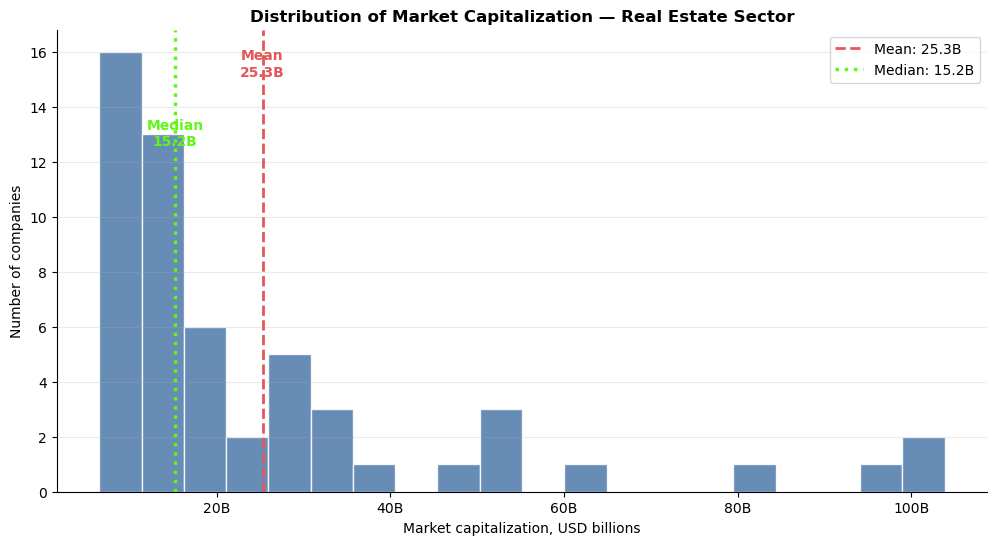

In [8]:
# ============================================================
# Step 1 — Market Capitalization Distribution
# ============================================================

# Select the market capitalization column for the assigned sector.
# We use the version expressed in USD billions to make the chart easier to read.
market_cap = df_sector["market_cap_b"].dropna()

# Compute mean and median.
mean_market_cap = market_cap.mean()
median_market_cap = market_cap.median()

# Create the histogram.
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(
    market_cap,
    bins=20,
    color="#4C78A8",
    edgecolor="white",
    alpha=0.85
)

# Add vertical line for the mean.
ax.axvline(
    mean_market_cap,
    color="#E45756",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {mean_market_cap:,.1f}B"
)

# Add vertical line for the median.
ax.axvline(
    median_market_cap,
    color="#62F518",
    linestyle=":",
    linewidth=2.5,
    label=f"Median: {median_market_cap:,.1f}B"
)

# Annotate the mean directly on the chart.
ax.text(
    mean_market_cap,
    ax.get_ylim()[1] * 0.90,
    f"Mean\n{mean_market_cap:,.1f}B",
    color="#E45756",
    ha="center",
    fontsize=10,
    fontweight="bold"
)

# Annotate the median directly on the chart.
ax.text(
    median_market_cap,
    ax.get_ylim()[1] * 0.75,
    f"Median\n{median_market_cap:,.1f}B",
    color="#62F518",
    ha="center",
    fontsize=10,
    fontweight="bold"
)

ax.set_title("Distribution of Market Capitalization — Real Estate Sector")
ax.set_xlabel("Market capitalization, USD billions")
ax.set_ylabel("Number of companies")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.grid(axis="y", alpha=0.25)
ax.legend()

clean_spines(ax)

plt.show()


 # Interpretation - Market Capitalization Distribution #

  The market capitalization distribution for the Real Estate sector is strongly right-skewed. Most companies are concentrated below 20B USD, while a few large firms reach values close to 100B USD. The mean market cap (25.3B) is substantially higher than the median (15.2B), suggesting that a small number of very large companies pull the average upward. This indicates that the median better represents the typical firm size in the sector. The right tail also suggests the possible presence of outliers.

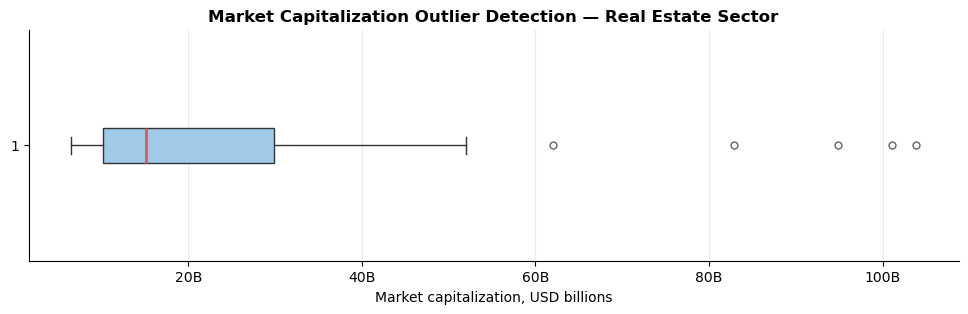

In [9]:
# ============================================================
# Step 2 — Outlier Detection
# ============================================================

# We start with the Real Estate sector dataset from Step 1.
# The goal is to detect whether very large market-cap companies behave as outliers.
market_cap = df_sector["market_cap_b"].dropna()

fig, ax = plt.subplots(figsize=(12, 3))

ax.boxplot(
    market_cap,
    vert=False,
    patch_artist=True,
    boxprops={"facecolor": "#A0CBE8", "edgecolor": "#333333"},
    medianprops={"color": "#E45756", "linewidth": 2},
    whiskerprops={"color": "#333333"},
    capprops={"color": "#333333"},
    flierprops={"marker": "o", "markersize": 5, "alpha": 0.6}
)

ax.set_title("Market Capitalization Outlier Detection — Real Estate Sector")
ax.set_xlabel("Market capitalization, USD billions")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.grid(axis="x", alpha=0.25)

clean_spines(ax)

plt.show()

In [10]:
# Compute IQR-based outlier thresholds.
q1 = market_cap.quantile(0.25)
q3 = market_cap.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"Q1: {q1:,.2f}B")
print(f"Q3: {q3:,.2f}B")
print(f"IQR: {iqr:,.2f}B")
print(f"Lower bound: {lower_bound:,.2f}B")
print(f"Upper bound: {upper_bound:,.2f}B")

Q1: 10.12B
Q3: 29.84B
IQR: 19.72B
Lower bound: -19.46B
Upper bound: 59.42B


In [11]:
# Identify companies above the upper bound.
market_cap_outliers = df_sector[df_sector["market_cap_b"] > upper_bound].copy()

market_cap_outliers[
    ["symbol", "company_name", "industry", "market_cap_b"]
].sort_values("market_cap_b", ascending=False)

,symbol,company_name,industry,market_cap_b
110,PLD,"Prologis, Inc.",REIT - Industrial,103.873184
112,AMT,American Tower Corporation (REI,REIT - Specialty,101.078221
122,WELL,Welltower Inc.,REIT - Healthcare Facilities,94.842986
136,EQIX,"Equinix, Inc.",REIT - Specialty,82.899657
193,SPG,"Simon Property Group, Inc.",REIT - Retail,62.003900


In [12]:

# Remove companies with market capitalization above the IQR upper bound.
# These companies are real and important, but they are much larger than the typical firm
# and could distort industry-level averages in the following steps.
df_sector_clean = df_sector[
    df_sector["market_cap_b"] <= upper_bound
].copy()

print("Original Real Estate dataset shape:", df_sector.shape)
print("Cleaned Real Estate dataset shape:", df_sector_clean.shape)
print("Removed outliers:", len(df_sector) - len(df_sector_clean))

display(
    market_cap_outliers[
        ["symbol", "company_name", "industry", "market_cap_b"]
    ].sort_values("market_cap_b", ascending=False)
)

Original Real Estate dataset shape: (55, 48)
Cleaned Real Estate dataset shape: (50, 48)
Removed outliers: 5


,symbol,company_name,industry,market_cap_b
110,PLD,"Prologis, Inc.",REIT - Industrial,103.873184
112,AMT,American Tower Corporation (REI,REIT - Specialty,101.078221
122,WELL,Welltower Inc.,REIT - Healthcare Facilities,94.842986
136,EQIX,"Equinix, Inc.",REIT - Specialty,82.899657
193,SPG,"Simon Property Group, Inc.",REIT - Retail,62.003900


In [13]:
# ============================================================
# Step 3 — Industry Comparison: Four metrics
# ============================================================

# We use the cleaned Real Estate dataset from Step 2.
# The goal is to compare industries using the mean value of four metrics:
# market capitalization, total revenue, profit margin, and beta.

industry_summary = (
    df_sector_clean
    .groupby("industry")
    .agg(
        mean_market_cap_b=("market_cap_b", "mean"),
        mean_total_revenue_b=("total_revenue_b", "mean"),
        mean_profit_margin_pct=("profit_margin_pct", "mean"),
        mean_beta=("beta", "mean"),
        company_count=("symbol", "count")
    )
)

# Sort industries by average market capitalization.
# This gives a stable order across the first chart and helps interpret sector structure.
industry_summary = industry_summary.sort_values("mean_market_cap_b", ascending=False)

industry_summary

,mean_market_cap_b,mean_total_revenue_b,mean_profit_margin_pct,mean_beta,company_count
industry,,,,,
REIT - Specialty,27.913954,4.528588,7.958714,1.062286,7
Real Estate Services,23.736666,32.122099,3.406600,0.773000,5
REIT - Diversified,23.653099,2.712796,49.414000,0.970500,2
REIT - Residential,19.462602,2.225580,21.990499,0.911700,10
REIT - Healthcare Facilities,18.231603,2.880285,16.437000,1.168667,3
REIT - Industrial,16.500396,1.984354,30.475334,0.850444,9
REIT - Retail,15.723257,1.828038,27.186428,1.196857,7
REIT - Office,12.299702,2.801307,4.821667,1.331667,3
REIT - Hotel & Motel,10.610058,5.691000,12.247000,1.328000,1


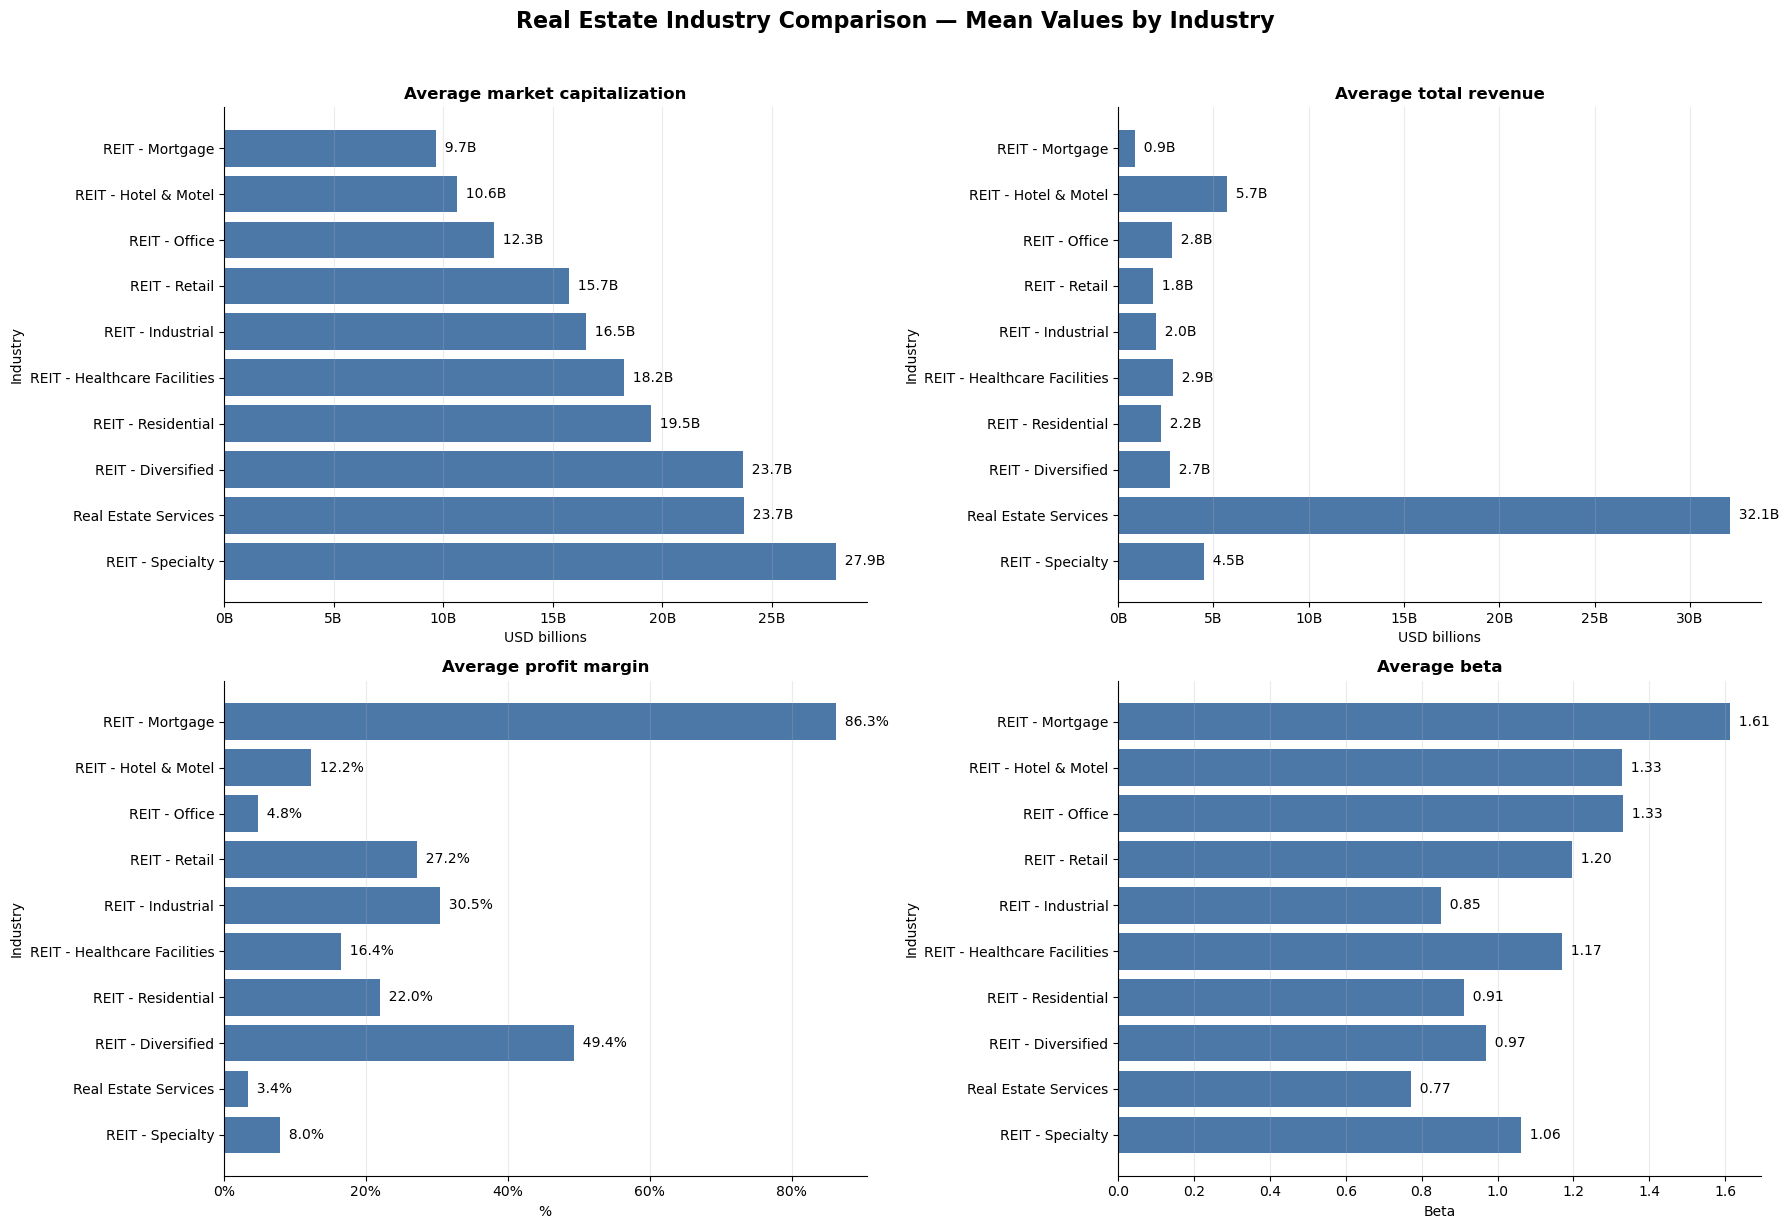

In [14]:
# Create one figure with 4 horizontal bar charts.
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(18, 12),
    sharey=False
)

# Flatten the axes array so it is easier to index.
axes = axes.flatten()

metrics = [
    ("mean_market_cap_b", "Average market capitalization", "USD billions", billions_formatter, "{:.1f}B"),
    ("mean_total_revenue_b", "Average total revenue", "USD billions", billions_formatter, "{:.1f}B"),
    ("mean_profit_margin_pct", "Average profit margin", "%", pct_formatter, "{:.1f}%"),
    ("mean_beta", "Average beta", "Beta", None, "{:.2f}")
]

for ax, (column, title, xlabel, formatter, label_fmt) in zip(axes, metrics):
    ax.barh(
        industry_summary.index,
        industry_summary[column],
        color="#4C78A8"
    )
    
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Industry")
    ax.grid(axis="x", alpha=0.25)
    
    if formatter is not None:
        ax.xaxis.set_major_formatter(FuncFormatter(formatter))
    
    annotate_hbar(ax, fmt=label_fmt)
    clean_spines(ax)

fig.suptitle(
    "Real Estate Industry Comparison — Mean Values by Industry",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

### Interpretation — Industry Comparison Using Mean Values

The Real Estate sector shows clear differences across industries. REIT - Specialty, Real Estate Services and REIT - Diversified have the highest average market capitalization, while REIT - Mortgage, REIT - Hotel & Motel and REIT - Office are smaller on average.

Real Estate Services stands out because it has by far the highest average total revenue, around 32.1B USD, but one of the lowest average profit margins, around 3.4%. This suggests that a large operating scale does not necessarily imply high profitability.

REIT - Mortgage shows the highest average profit margin, around 86.3%, but also the highest beta, around 1.61. This may indicate a more profitable but also riskier industry profile.

REIT - Industrial looks relatively balanced, with a solid average profit margin of about 30.5% and a relatively low beta of 0.85.

These results should be interpreted carefully because they are based on averages.

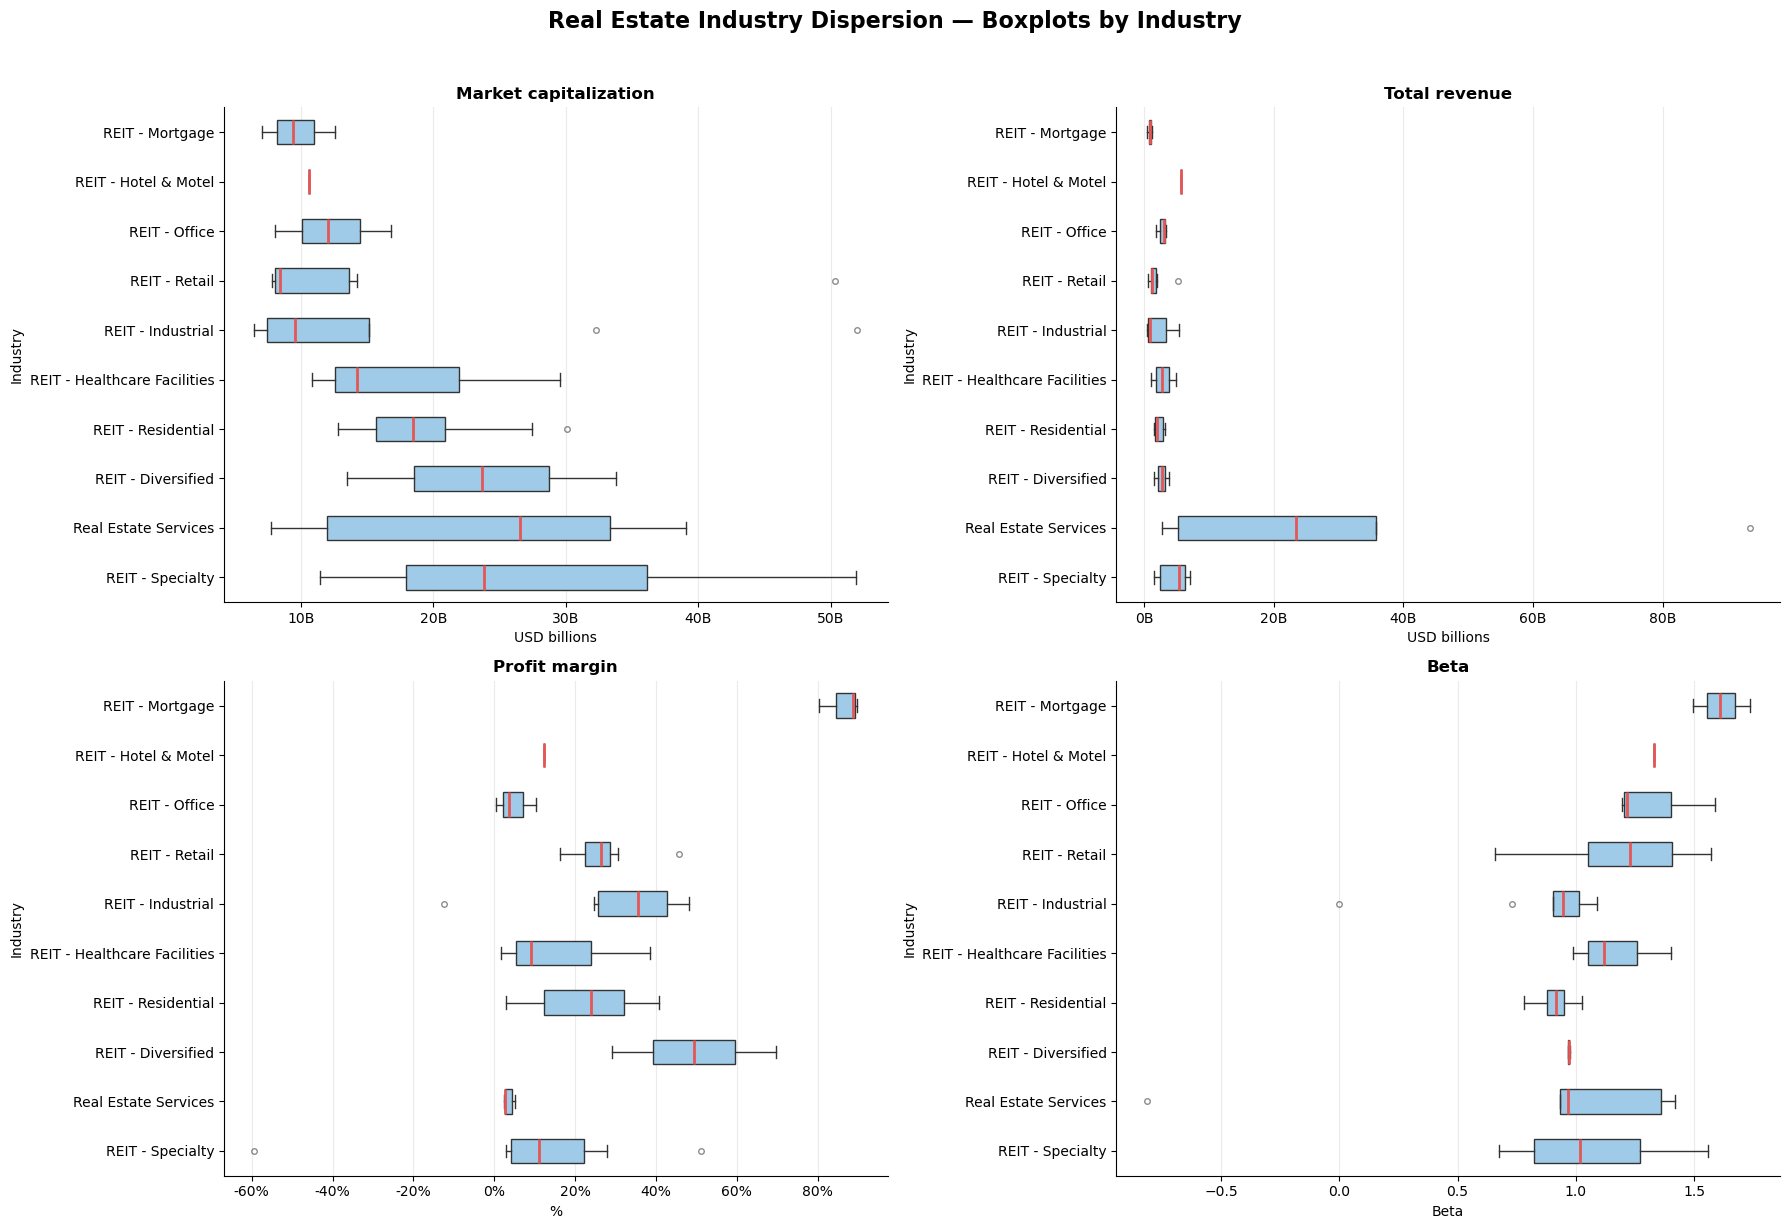

In [15]:
# ============================================================
# Step 4 — Industry Dispersion
# ============================================================

# We use the cleaned Real Estate dataset from Step 2.
# Boxplots allow us to inspect the full distribution of each metric by industry,
# instead of looking only at industry averages.

metrics = [
    ("market_cap_b", "Market capitalization", "USD billions", billions_formatter),
    ("total_revenue_b", "Total revenue", "USD billions", billions_formatter),
    ("profit_margin_pct", "Profit margin", "%", pct_formatter),
    ("beta", "Beta", "Beta", None)
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(18, 12),
    sharey=False
)

axes = axes.flatten()

# We keep a common industry order based on average market cap from Step 3.
# This makes the charts easier to compare visually.
industry_order = industry_summary.index.tolist()

for ax, (column, title, xlabel, formatter) in zip(axes, metrics):
    
    # Build the input data for the boxplot:
    # one numeric array for each industry, following industry_order.
    box_data = [
        df_sector_clean.loc[df_sector_clean["industry"] == industry, column].dropna().values
        for industry in industry_order
    ]
    
    ax.boxplot(
        box_data,
        tick_labels=industry_order,
        vert=False,
        patch_artist=True,
        boxprops={"facecolor": "#A0CBE8", "edgecolor": "#333333"},
        medianprops={"color": "#E45756", "linewidth": 2},
        whiskerprops={"color": "#333333"},
        capprops={"color": "#333333"},
        flierprops={"marker": "o", "markersize": 4, "alpha": 0.45}
    )
    
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Industry")
    ax.grid(axis="x", alpha=0.25)
    
    if formatter is not None:
        ax.xaxis.set_major_formatter(FuncFormatter(formatter))
    
    clean_spines(ax)

fig.suptitle(
    "Real Estate Industry Dispersion — Boxplots by Industry",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

### Interpretation — Industry Dispersion

The boxplots show that the Real Estate industries differ not only in their average values, but also in their internal dispersion.

For market capitalization, REIT - Specialty, Real Estate Services and REIT - Diversified remain among the largest groups, but Real Estate Services shows a wide spread, meaning that companies in this industry differ strongly in size. Some industries, such as REIT - Industrial and REIT - Retail, still contain high-end observations even after removing the main market-cap outliers.

For total revenue, Real Estate Services clearly stands out. Its distribution is much more shifted to the right than the other industries, and it also contains a very large revenue outlier. This confirms that the high average revenue observed in Step 3 is driven by the operating scale of this industry, although not all companies inside it are equally large.

Profit margin shows very different industry profiles. REIT - Mortgage has very high margins, while REIT - Diversified and REIT - Industrial also show strong profitability. In contrast, Real Estate Services and REIT - Office have low margins, suggesting that high revenue does not necessarily imply high profitability.

Beta highlights differences in risk. REIT - Mortgage has the highest beta values, while REIT - Office, REIT - Hotel & Motel and REIT - Retail also appear relatively more volatile. REIT - Industrial, REIT - Residential and Real Estate Services show more moderate beta values.



In [16]:
# ============================================================
# Step 5 — Focus Industry Selection
# ============================================================

# Based on previous analysis, I  select four industries with distinct analytical profiles:

focus_industries = [
    "Real Estate Services",
    "REIT - Industrial",
    "REIT - Diversified",
    "REIT - Mortgage"
]

# Filter the cleaned Real Estate dataset to the selected industries only.
df_focus = df_sector_clean[
    df_sector_clean["industry"].isin(focus_industries)
].copy()

print("Cleaned Real Estate dataset shape:", df_sector_clean.shape)
print("Focus dataset shape:", df_focus.shape)

# Check how many companies remain in each selected industry.
df_focus["industry"].value_counts()

Cleaned Real Estate dataset shape: (50, 48)
Focus dataset shape: (19, 48)


industry
REIT - Industrial       9
Real Estate Services    5
REIT - Mortgage         3
REIT - Diversified      2
Name: count, dtype: int64

### Step 5 — Focus Industry Selection

Based on the industry comparison and dispersion charts, I selected four industries for the next steps: Real Estate Services, REIT - Industrial, REIT - Diversified and REIT - Mortgage. The resulting focus universe contains 19 companies.

REIT - Industrial is the largest selected group, with 9 companies. It is kept because it appears relatively balanced: it has a solid average profit margin of about 30.5% and a relatively low beta of about 0.85. This makes it a useful benchmark group with moderate risk and good profitability.

Real Estate Services includes 5 companies and is kept because it has by far the highest average total revenue, around 32.1B USD, but one of the lowest average profit margins, around 3.4%. This makes it useful to study the difference between operating scale and profitability.

REIT - Mortgage includes only 3 companies, so its results must be interpreted carefully. However, it is kept because it has the highest average profit margin, around 86.3%, and also the highest average beta, around 1.61. This makes it analytically interesting as a high-profitability, high-risk group.

REIT - Diversified includes only 2 companies, so it is also a small group. Still, it is kept because it combines high average market capitalization, around 23.7B USD, high average profit margin, around 49.4%, and beta close to 1. This gives it a distinct large-and-profitable profile.

The other industries are excluded to keep the focus universe manageable and easier to interpret. REIT - Office and REIT - Hotel & Motel show relatively high beta values but weaker profitability profiles. REIT - Retail is also relatively risky, but less distinctive than REIT - Mortgage. REIT - Healthcare Facilities and REIT - Residential show more intermediate profiles. REIT - Specialty is excluded because, although it has high average market capitalization, its profit margin distribution is highly dispersed and includes a strong negative outlier.

### Step 6 — Bubble Chart 

In this step, I use a bubble chart to compare the companies in the selected Real Estate focus universe across multiple dimensions at the same time.

I choose **beta** for the x-axis because it represents market risk or sensitivity to market movements. A beta below 1 indicates that a company is less volatile than the market, while a beta above 1 indicates higher market sensitivity.

I choose **profit margin** for the y-axis because it measures profitability. This allows the chart to distinguish between companies that are more profitable and companies that generate lower margins.

I use **market capitalization** as the bubble size because it shows the economic size of each company. Larger bubbles represent larger firms, making it easier to see whether the most relevant companies are concentrated in specific areas of the chart.

I use **industry** as the bubble color because the focus universe includes different Real Estate industries. Coloring by industry helps reveal whether certain industries tend to cluster in specific risk-profitability profiles.

The chart is divided into four quadrants. The vertical line is set at **beta = 1**, because this is the natural threshold between companies that are less or more sensitive than the overall market. The horizontal line is set at the **median profit margin** of the focus universe, so high and low profitability are defined relative to the selected companies rather than using an arbitrary external threshold.

The four quadrants therefore represent:
- **Low beta / High margin**: companies with lower market sensitivity and above-median profitability.
- **High beta / High margin**: companies with higher market sensitivity but also above-median profitability.
- **Low beta / Low margin**: companies with lower market sensitivity but weaker profitability.
- **High beta / Low margin**: companies with both higher market sensitivity and weaker profitability.

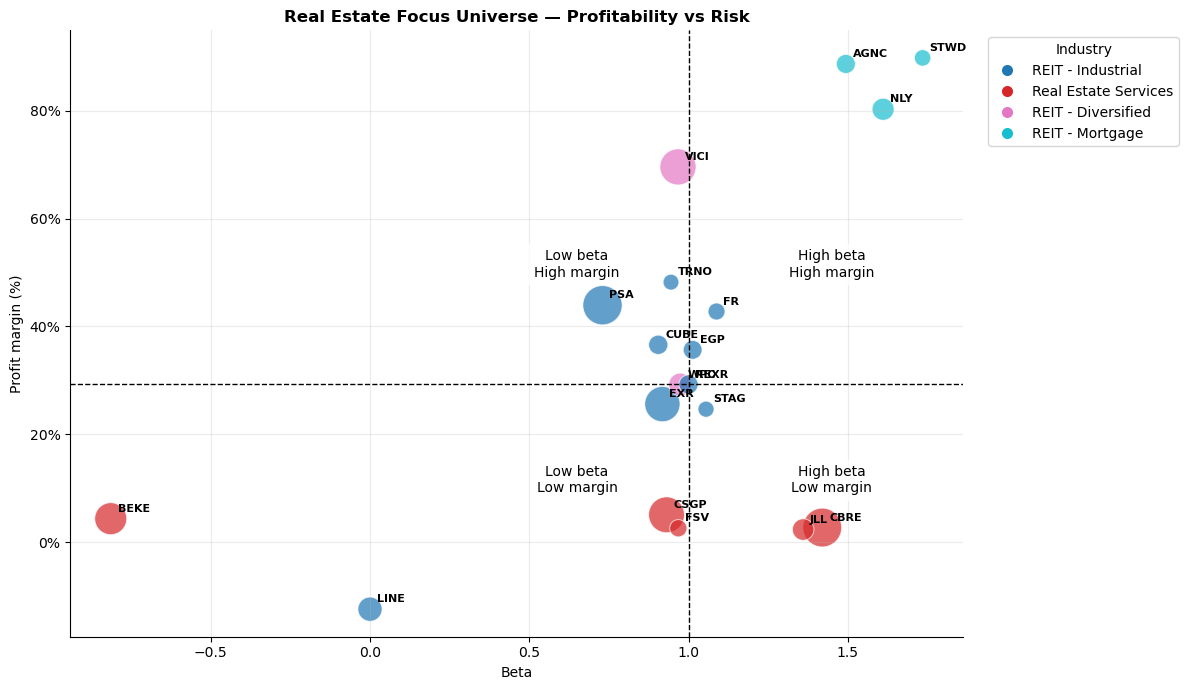

In [17]:


bubble_df = df_focus.dropna(
    subset=["beta", "profit_margin_pct", "market_cap_b", "industry", "symbol"]
).copy()

beta_threshold = 1.0
profit_margin_threshold = bubble_df["profit_margin_pct"].median()

# Scale bubble sizes.
# Dividing by 2 makes bubbles visually manageable.
# clip() avoids bubbles that are too small or too large.
sizes = (bubble_df["market_cap_b"] * 20).clip(lower=80, upper=800)

# Create one color per industry.
industries = bubble_df["industry"].unique()
palette = plt.cm.tab10(np.linspace(0, 1, len(industries)))
industry_to_color = dict(zip(industries, palette))
colors = bubble_df["industry"].map(industry_to_color)

fig, ax = plt.subplots(figsize=(12, 7))

points = ax.scatter(
    bubble_df["beta"],
    bubble_df["profit_margin_pct"],
    s=sizes,
    c=colors,
    alpha=0.70,
    edgecolors="white",
    linewidth=0.7
)

# Add quadrant reference lines.
ax.axvline(beta_threshold, color="black", linewidth=1, linestyle="--")
ax.axhline(profit_margin_threshold, color="black", linewidth=1, linestyle="--")

# Annotate each company with its ticker.
for _, row in bubble_df.iterrows():
    ax.annotate(
        row["symbol"],
        (row["beta"], row["profit_margin_pct"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        weight="bold"
    )

# Add quadrant labels.
ax.text(
    0.65, profit_margin_threshold + 20,
    "Low beta\nHigh margin",
    fontsize=10,
    ha="center",
    bbox=dict(facecolor="white", alpha=0.75, edgecolor="none")
)

ax.text(
    1.45, profit_margin_threshold + 20,
    "High beta\nHigh margin",
    fontsize=10,
    ha="center",
    bbox=dict(facecolor="white", alpha=0.75, edgecolor="none")
)

ax.text(
    0.65, profit_margin_threshold - 20,
    "Low beta\nLow margin",
    fontsize=10,
    ha="center",
    bbox=dict(facecolor="white", alpha=0.75, edgecolor="none")
)

ax.text(
    1.45, profit_margin_threshold - 20,
    "High beta\nLow margin",
    fontsize=10,
    ha="center",
    bbox=dict(facecolor="white", alpha=0.75, edgecolor="none")
)

ax.set_title("Real Estate Focus Universe — Profitability vs Risk")
ax.set_xlabel("Beta")
ax.set_ylabel("Profit margin (%)")
ax.yaxis.set_major_formatter(FuncFormatter(pct_formatter))
ax.grid(alpha=0.25)

clean_spines(ax)

# Custom legend for industries.
legend_handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        label=industry,
        markerfacecolor=color,
        markersize=9
    )
    for industry, color in industry_to_color.items()
]

ax.legend(
    handles=legend_handles,
    title="Industry",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Interpretation — Bubble Chart

The bubble chart compares the selected Real Estate companies using beta on the x-axis and profit margin on the y-axis. Bubble size represents market capitalization, while color identifies the industry.

The chart shows a clear separation between different industry profiles. REIT - Mortgage companies are concentrated in the high beta / high margin quadrant. Companies such as STWD, AGNC and NLY show very high profit margins, around 80%–90%, but they also have beta values above 1. This confirms that REIT - Mortgage has a high-profitability but higher-risk profile.

Real Estate Services companies are mostly located in the low-margin area. CSGP, FSV, JLL and CBRE show profit margins close to zero, even though some of them have relatively large market capitalizations. BEKE is an unusual observation because it has a negative beta and low profitability, meaning that it behaves differently from the rest of the focus universe.

REIT - Industrial companies are more spread across the central part of the chart. Some firms, such as PSA, TRNO, CUBE, EGP and FR, combine moderate-to-high margins with beta values close to 1, while others such as EXR, STAG and LINE show weaker or more unusual profiles. This suggests that REIT - Industrial is internally heterogeneous.

REIT - Diversified has only a small number of companies, but VICI stands out as a large company with high profit margin and beta close to 1. This makes it one of the more interesting companies in the focus universe.


In [18]:
# Assign companies to quadrants


def assign_quadrant(row):
    if row["beta"] <= beta_threshold and row["profit_margin_pct"] >= profit_margin_threshold:
        return "Low beta / High margin"
    elif row["beta"] > beta_threshold and row["profit_margin_pct"] >= profit_margin_threshold:
        return "High beta / High margin"
    elif row["beta"] <= beta_threshold and row["profit_margin_pct"] < profit_margin_threshold:
        return "Low beta / Low margin"
    else:
        return "High beta / Low margin"

bubble_df["quadrant"] = bubble_df.apply(assign_quadrant, axis=1)

print("Profit margin threshold:", round(profit_margin_threshold, 2))
print("Beta threshold:", beta_threshold)

bubble_df[
    ["symbol", "company_name", "industry", "market_cap_b", "profit_margin_pct", "beta", "quadrant"]
].sort_values(["quadrant", "market_cap_b"], ascending=[True, False])


Profit margin threshold: 29.24
Beta threshold: 1.0


,symbol,company_name,industry,market_cap_b,profit_margin_pct,beta,quadrant
658,NLY,Annaly Capital Management Inc.,REIT - Mortgage,12.585068,80.290002,1.611,High beta / High margin
795,AGNC,AGNC Investment Corp.,REIT - Mortgage,9.424753,88.695002,1.494,High beta / High margin
806,EGP,"EastGroup Properties, Inc.",REIT - Industrial,9.201489,35.668001,1.013,High beta / High margin
916,FR,"First Industrial Realty Trust,",REIT - Industrial,7.477808,42.778999,1.088,High beta / High margin
944,STWD,"STARWOOD PROPERTY TRUST, INC. S",REIT - Mortgage,7.036188,89.815003,1.735,High beta / High margin
300,CBRE,CBRE Group Inc,Real Estate Services,39.043924,2.706000,1.420,High beta / Low margin
682,JLL,Jones Lang LaSalle Incorporated,Real Estate Services,12.005293,2.333000,1.360,High beta / Low margin
967,STAG,"Stag Industrial, Inc.",REIT - Industrial,6.690339,24.658000,1.055,High beta / Low margin
231,PSA,Public Storage,REIT - Industrial,52.007211,43.941003,0.730,Low beta / High margin
328,VICI,VICI Properties Inc.,REIT - Diversified,33.825069,69.594002,0.967,Low beta / High margin


In [19]:
bubble_df["quadrant"].value_counts()

quadrant
Low beta / Low margin      6
Low beta / High margin     5
High beta / High margin    5
High beta / Low margin     3
Name: count, dtype: int64

### Step 7 — Zoom into one quadrant

For Step 7, I select the **High beta / High margin** quadrant. This group contains companies with above-median profitability and beta values above 1. In other words, these firms combine strong profitability with higher market sensitivity.

This quadrant is interesting because high-beta companies are expected to react more strongly to market uncertainty. Since the homework asks to reflect on recent geopolitical tensions, especially around the Strait of Hormuz, this quadrant provides a useful group to test whether more market-sensitive companies showed visible price pressure, volatility, or recovery over the last three months.

I use market capitalization because it selects the largest and most economically relevant companies within the quadrant.

In [20]:

# We select the High beta / High margin quadrant because it combines
# above-median profitability with above-market risk sensitivity.
selected_quadrant = "High beta / High margin"

df_step7 = bubble_df[
    bubble_df["quadrant"] == selected_quadrant
].copy()

# If more than 10 companies are present, keep the top 10 by market capitalization.
# Market capitalization is used because it selects the largest and most economically relevant firms.
df_step7 = df_step7.sort_values("market_cap_b", ascending=False).head(10).copy()

print("Selected quadrant:", selected_quadrant)
print("Number of companies selected:", len(df_step7))

df_step7[
    ["symbol", "company_name", "industry", "market_cap_b", "profit_margin_pct", "beta", "quadrant"]
]

Selected quadrant: High beta / High margin
Number of companies selected: 5


,symbol,company_name,industry,market_cap_b,profit_margin_pct,beta,quadrant
658,NLY,Annaly Capital Management Inc.,REIT - Mortgage,12.585068,80.290002,1.611,High beta / High margin
795,AGNC,AGNC Investment Corp.,REIT - Mortgage,9.424753,88.695002,1.494,High beta / High margin
806,EGP,"EastGroup Properties, Inc.",REIT - Industrial,9.201489,35.668001,1.013,High beta / High margin
916,FR,"First Industrial Realty Trust,",REIT - Industrial,7.477808,42.778999,1.088,High beta / High margin
944,STWD,"STARWOOD PROPERTY TRUST, INC. S",REIT - Mortgage,7.036188,89.815003,1.735,High beta / High margin


In [21]:
#  Download last 3 months of prices


import yfinance as yf

# Build ticker list from the selected quadrant.
tickers_step7 = df_step7["symbol"].tolist()

print("Tickers selected for Step 7:", tickers_step7)

# Download daily adjusted closing prices for the last 3 months.
price_data_step7 = yf.download(
    tickers_step7,
    period="3mo",
    interval="1d",
    auto_adjust=True
)

closing_prices_step7 = price_data_step7["Close"]

# Display the first rows to check the data structure.
closing_prices_step7.head()

Tickers selected for Step 7: ['NLY', 'AGNC', 'EGP', 'FR', 'STWD']


[*********************100%***********************]  5 of 5 completed


Ticker,AGNC,EGP,FR,NLY,STWD
Date,,,,,
2026-02-13,10.981369,189.307236,58.405502,22.310404,17.570656
2026-02-17,10.923369,191.201096,59.525639,22.223368,17.580379
2026-02-18,10.933036,189.684021,59.872585,22.242710,17.609552
2026-02-19,10.942702,189.029602,60.199699,22.223368,17.512314
2026-02-20,11.068370,191.290329,61.537914,22.262053,17.560932


In [22]:
# Normalized prices

# Normalize each price series to 1 on the first available trading day.
# This makes the relative performance directly comparable across stocks.
normalized_prices_step7 = closing_prices_step7 / closing_prices_step7.iloc[0]

normalized_prices_step7.head()

Ticker,AGNC,EGP,FR,NLY,STWD
Date,,,,,
2026-02-13,1.000000,1.000000,1.000000,1.000000,1.000000
2026-02-17,0.994718,1.010004,1.019179,0.996099,1.000553
2026-02-18,0.995599,1.001990,1.025119,0.996966,1.002214
2026-02-19,0.996479,0.998533,1.030720,0.996099,0.996680
2026-02-20,1.007923,1.010476,1.053632,0.997833,0.999447


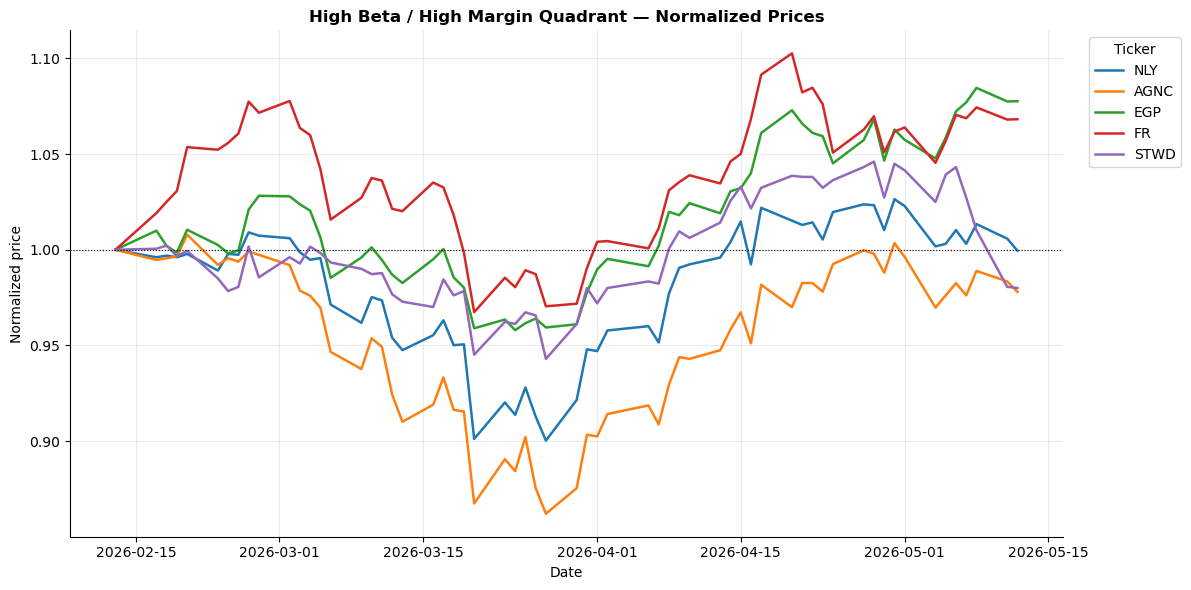

In [23]:
 
# Plot normalized price performance

fig, ax = plt.subplots(figsize=(12, 6))

for ticker in tickers_step7:
    ax.plot(
        normalized_prices_step7.index,
        normalized_prices_step7[ticker],
        linewidth=1.8,
        label=ticker
    )

# Reference line at 1 = no change from the first trading day.
ax.axhline(1, color="black", linewidth=0.8, linestyle=":")

ax.set_title("High Beta / High Margin Quadrant — Normalized Prices")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized price")

ax.grid(alpha=0.25)
clean_spines(ax)

ax.legend(title="Ticker", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [24]:
#  Final 3-month performance

performance_step7 = (
    (normalized_prices_step7.iloc[-1] - 1) * 100
).sort_values(ascending=False)

performance_step7_df = performance_step7.reset_index()
performance_step7_df.columns = ["symbol", "three_month_return_pct"]

performance_step7_df

,symbol,three_month_return_pct
0,EGP,7.761333
1,FR,6.822126
2,NLY,-0.046636
3,STWD,-1.995694
4,AGNC,-2.197989


### Interpretation — Price Performance of the High Beta / High Margin Quadrant

The selected quadrant contains companies with above-median profit margins and beta values above 1. This makes the group interesting because these firms combine strong profitability with higher sensitivity to market movements.

The selected companies are NLY, AGNC, EGP, FR and STWD. Three of them belong to REIT - Mortgage, while two belong to REIT - Industrial. All companies have high profit margins, but the Mortgage REITs also show particularly high beta values.

The normalized price chart shows a common decline between mid-March and late March. AGNC experienced the strongest drawdown, falling to around 0.86 at its lowest point, while NLY also declined substantially during the same period. EGP, FR and STWD were more resilient, although they also experienced some pressure around March.

From early April onward, the group recovered clearly, but the recovery was not equally strong across all companies. EGP and FR recovered the most and ended the period with positive returns of about +7.8% and +6.8%, respectively. NLY finished almost flat, with a return close to 0%, while STWD and AGNC remained negative, with returns of about -2.0% and -2.2%.

This means that the High beta / High margin quadrant did not show a uniform performance. The two REIT - Industrial companies, EGP and FR, were the strongest performers, while the REIT - Mortgage companies were weaker despite their very high profit margins. Therefore, high profitability alone did not guarantee positive stock performance over the three-month period.

In relation to the geopolitical tensions around the Strait of Hormuz, the chart suggests that this high-beta group experienced a period of pressure and volatility, especially around March. However, the effect does not appear to be a persistent collapse for the whole group. Instead, the chart shows a recovery from April onward, although the final performance differs significantly across companies and industries.

### Step 8 — Compare with an Excluded Quadrant

For Step 8, I select the **Low beta / Low margin** quadrant as a comparison group. This quadrant is useful because it contrasts directly with the group analyzed in Step 7.

In Step 7, the selected companies had high profit margins and beta values above 1, meaning they were profitable but more sensitive to market movements. In this step, I analyze companies with lower beta and lower profitability. This allows me to check whether lower-beta companies showed more stable price behavior during the same three-month period.

As in Step 7, if the quadrant contains more than 10 companies, I keep the top 10 by market capitalization. I use the same selection criterion to make the comparison consistent.

In [25]:
# Select excluded quadrant for comparison


comparison_quadrant = "Low beta / Low margin"

df_step8 = bubble_df[
    bubble_df["quadrant"] == comparison_quadrant
].copy()

df_step8 = df_step8.sort_values("market_cap_b", ascending=False).head(10).copy()

print("Comparison quadrant:", comparison_quadrant)
print("Number of companies selected:", len(df_step8))

df_step8[
    ["symbol", "company_name", "industry", "market_cap_b", "profit_margin_pct", "beta", "quadrant"]
]

Comparison quadrant: Low beta / Low margin
Number of companies selected: 6


,symbol,company_name,industry,market_cap_b,profit_margin_pct,beta,quadrant
330,CSGP,"CoStar Group, Inc.",Real Estate Services,33.327688,5.069000,0.931,Low beta / Low margin
340,EXR,Extra Space Storage Inc,REIT - Industrial,32.288565,25.604999,0.918,Low beta / Low margin
397,BEKE,KE Holdings Inc,Real Estate Services,26.567395,4.349000,-0.814,Low beta / Low margin
585,LINE,"Lineage, Inc.",REIT - Industrial,15.185168,-12.434000,0.000,Low beta / Low margin
634,WPC,W. P. Carey Inc. REIT,REIT - Diversified,13.481129,29.233998,0.974,Low beta / Low margin
904,FSV,FirstService Corporation,Real Estate Services,7.739028,2.576000,0.968,Low beta / Low margin


In [26]:
#  Download last 3 months of prices

# Build ticker list from the selected comparison quadrant.
tickers_step8 = df_step8["symbol"].tolist()

print("Tickers selected for Step 8:", tickers_step8)

# Download daily adjusted closing prices for the last 3 months.
price_data_step8 = yf.download(
    tickers_step8,
    period="3mo",
    interval="1d",
    auto_adjust=True
)

closing_prices_step8 = price_data_step8["Close"]

closing_prices_step8.head()

Tickers selected for Step 8: ['CSGP', 'EXR', 'BEKE', 'LINE', 'WPC', 'FSV']


[*********************100%***********************]  6 of 6 completed


Ticker,BEKE,CSGP,EXR,FSV,LINE,WPC
Date,,,,,,
2026-02-13,17.231119,44.990002,144.682816,154.303680,37.196728,73.183861
2026-02-17,16.867844,45.740002,146.145859,153.954468,36.498611,73.144417
2026-02-18,16.907116,48.939999,143.516327,156.508743,35.997150,70.412346
2026-02-19,16.808933,49.070000,144.415909,155.710526,38.347141,70.816734
2026-02-20,16.956207,49.869999,150.999588,155.401215,37.658859,71.388786


In [27]:
# Normalized prices

# Normalize each price series to 1 on the first available trading day.
# This makes the relative performance directly comparable across companies.
normalized_prices_step8 = closing_prices_step8 / closing_prices_step8.iloc[0]

normalized_prices_step8.head()

Ticker,BEKE,CSGP,EXR,FSV,LINE,WPC
Date,,,,,,
2026-02-13,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2026-02-17,0.978917,1.016670,1.010112,0.997737,0.981232,0.999461
2026-02-18,0.981197,1.087797,0.991938,1.014290,0.967750,0.962129
2026-02-19,0.975499,1.090687,0.998155,1.009117,1.030928,0.967655
2026-02-20,0.984046,1.108468,1.043659,1.007113,1.012424,0.975472


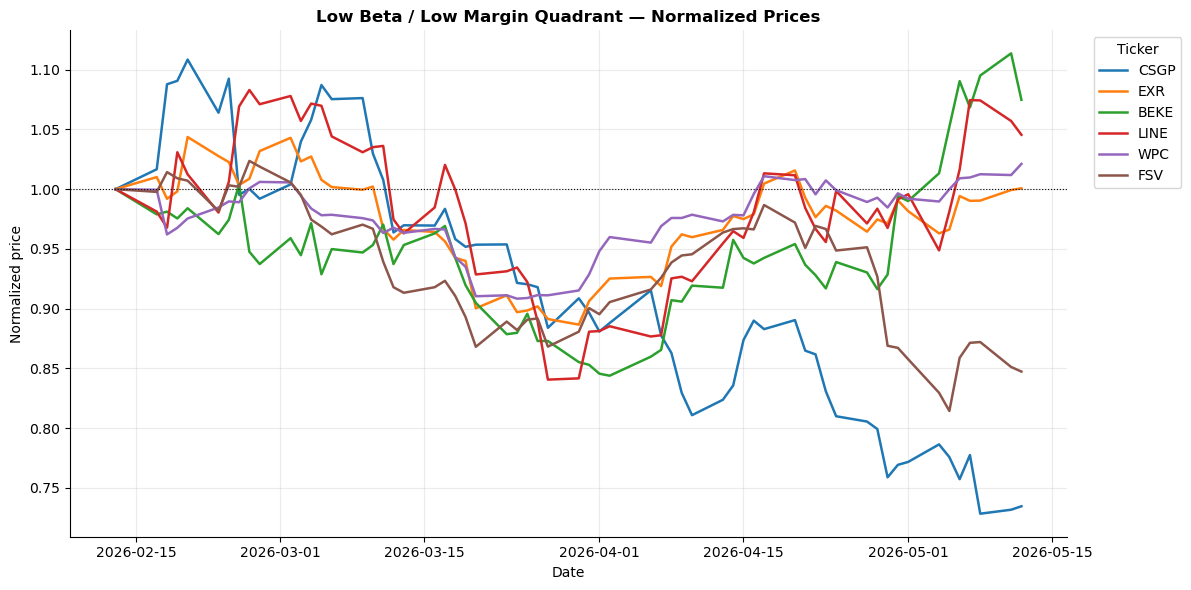

In [28]:
#  Plot normalized price performance

fig, ax = plt.subplots(figsize=(12, 6))

for ticker in tickers_step8:
    ax.plot(
        normalized_prices_step8.index,
        normalized_prices_step8[ticker],
        linewidth=1.8,
        label=ticker
    )

# Reference line at 1 = no change from the first trading day.
ax.axhline(1, color="black", linewidth=0.8, linestyle=":")

ax.set_title("Low Beta / Low Margin Quadrant — Normalized Prices")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized price")

ax.grid(alpha=0.25)
clean_spines(ax)

ax.legend(title="Ticker", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [29]:
#  Final 3-month performance

performance_step8 = (
    (normalized_prices_step8.iloc[-1] - 1) * 100
).sort_values(ascending=False)

performance_step8_df = performance_step8.reset_index()
performance_step8_df.columns = ["symbol", "three_month_return_pct"]

performance_step8_df

,symbol,three_month_return_pct
0,BEKE,7.479963
1,LINE,4.552206
2,WPC,2.112682
3,EXR,0.074078
4,FSV,-15.264497
5,CSGP,-26.539235


### Interpretation — Comparison with the Low Beta / Low Margin Quadrant

The comparison quadrant selected for Step 8 is **Low beta / Low margin**. The goal was to check whether companies with lower beta showed more stable price behavior over the same three-month period.

The selected companies are CSGP, EXR, BEKE, LINE, WPC and FSV. Their final three-month performances are quite dispersed. BEKE is the best performer, with a return of about +7.5%, followed by LINE at about +4.6% and WPC at about +2.1%. EXR finishes almost flat, with a return close to 0%. On the negative side, FSV declines by about -15.3%, while CSGP is the weakest performer, with a return of about -26.5%.

The chart shows that the Low beta / Low margin group did not behave uniformly. Some companies recovered strongly from the March decline and ended the period above their starting value, especially BEKE and LINE. However, CSGP and FSV experienced persistent weakness and did not recover by the end of the period. This means that lower beta did not automatically translate into better downside protection.

Compared with Step 7, the Low beta / Low margin group shows a more polarized performance. In the High beta / High margin quadrant, EGP and FR were clearly positive, NLY was almost flat, and STWD and AGNC were slightly negative. In this Low beta / Low margin group, the best performers were positive as well, but the weakest companies suffered much larger losses. Therefore, the lower-beta group was not necessarily more resilient overall.

This comparison suggests that beta alone was not sufficient to explain the three-month stock performance. Profitability, company-specific factors and industry differences also appear to matter. In particular, the low-margin group included both recovering companies and companies with substantial declines, while the high-margin group showed more moderate losses among its weakest performers.

In relation to the geopolitical tensions around the Strait of Hormuz, this group does not show a uniform reaction. The market context may have contributed to overall volatility, especially around March, but the differences between companies are too large to be explained only by geopolitical risk. Company-specific fundamentals and industry-level dynamics likely played an important role.

## Final Summary

This homework analyzed the **Real Estate** sector through a sector deep dive based on company fundamentals, industry structure, risk-profitability profiles and recent stock price performance.

After the initial cleaning process, the Real Estate dataset contained 55 companies across 10 industries. The market capitalization distribution was clearly right-skewed: most companies were concentrated below 20B USD, while a few firms reached values above 80B–100B. The mean market capitalization was about 25.3B USD, higher than the median of about 15.2B USD, showing that a small number of large firms pulled the average upward. Using the IQR rule, five high-end market-cap outliers were identified and removed, leaving a cleaned dataset of 50 companies for the following steps.

The industry comparison showed very different profiles inside the sector. Real Estate Services had by far the highest average total revenue, around 32.1B USD, but very low average profit margin, around 3.4%. REIT - Mortgage had the highest profit margin, around 86.3%, but also the highest beta, around 1.61. REIT - Industrial appeared more balanced, with solid profitability and relatively low beta, while REIT - Diversified combined high average market capitalization with strong profitability.

Based on these patterns, I selected four focus industries: **Real Estate Services, REIT - Industrial, REIT - Diversified and REIT - Mortgage**. These industries were chosen because they represent distinct analytical profiles: high scale but low profitability, balanced profitability and risk, large and profitable firms, and high-profitability but high-risk firms.

The bubble chart compared companies using beta on the x-axis, profit margin on the y-axis, market capitalization as bubble size and industry as color. It revealed a clear separation between the selected industries. REIT - Mortgage companies were mostly concentrated in the high beta / high margin quadrant, while Real Estate Services companies were mostly low-margin. REIT - Industrial was more mixed, and VICI stood out within REIT - Diversified as a large and profitable company close to market-level beta.

For the price-performance analysis, I first selected the **High beta / High margin** quadrant. Over the last three months, the group showed a clear decline around March, followed by a recovery from April onward. However, the final performance was mixed: EGP and FR ended with strong positive returns of about +7.8% and +6.8%, respectively, while NLY finished almost flat. STWD and AGNC remained slightly negative, with returns of about -2.0% and -2.2%.

I then compared this group with the **Low beta / Low margin** quadrant. This group was more polarized. BEKE, LINE and WPC ended with positive returns, while EXR was almost flat. However, FSV and CSGP suffered much larger losses, around -15.3% and -26.5%. This suggests that lower beta did not automatically provide better downside protection. Overall, beta alone did not fully explain stock behavior: profitability, company-specific factors and industry differences also played an important role.